In [25]:
import io
import os
import fnmatch
from typing import Optional
import paramiko
import pandas as pd

def fetch_and_concat_csvs(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    pattern: str = "df_metrics*",
    port: int = 22,
    return_csv_string: bool = False,
    timeout: Optional[float] = 10.0,
) -> pd.DataFrame:
    """
    Se connecte en SFTP et télécharge/télécharge en mémoire tous les fichiers
    du dossier `remote_dir` qui correspondent au `pattern` (fnmatch), lit les CSV,
    ajoute une colonne 'file' contenant le nom du fichier, concatène et renvoie
    le DataFrame final.

    Paramètres
    ----------
    ip, user, password : str
        Informations de connexion SSH.
    remote_dir : str
        Dossier distant à parcourir (chemin absolu ou relatif à l'utilisateur SFTP).
    pattern : str
        Pattern shell-style (ex: 'df_metrics*').
    port : int
        Port SSH (par défaut 22).
    return_csv_string : bool
        Si True, renvoie une tuple (DataFrame, csv_string). Sinon seulement DataFrame.
    timeout : float|None
        Timeout connexion en secondes.

    Retour
    ------
    pd.DataFrame
        DataFrame pandas concaténé contenant tous les enregistrements et une colonne 'file'.
        (ou (DataFrame, csv_string) si return_csv_string=True)
    """

    # Prépare le client SSH / SFTP
    transport = None
    sftp = None
    try:
        # Connexion SSH (transport)
        transport = paramiko.Transport((ip, port))
        transport.connect(username=user, password=password)
        # Ouvrir SFTP
        sftp = paramiko.SFTPClient.from_transport(transport)

        # Lister fichiers dans le répertoire distant
        try:
            files = sftp.listdir(remote_dir)
        except IOError:
            # Peut-être remote_dir non trouvé ; relancer en absolu ou lever l'erreur
            raise

        # Filtrer par pattern
        matched = [f for f in files if fnmatch.fnmatch(f, pattern)]
        if not matched:
            # Aucun fichier trouvé : renvoyer DataFrame vide
            empty_df = pd.DataFrame()
            if return_csv_string:
                return empty_df, ""
            return empty_df

        dfs = []
        for fname in matched:
            if 'volting' in fname or 'federated' in fname:
                continue
            print(fname)
            #if 'tree' not in fname:
            #    continue
            remote_path = os.path.join(remote_dir, fname)
            # Ouvre en binaire, lit tout en mémoire
            with sftp.open(remote_path, "rb") as remote_file:
                raw = remote_file.read()
            # Tenter de lire avec pandas
            # On essaie d'abord BytesIO (pandas gère souvent les bytes),
            # sinon on décode en utf-8 en tolérant les erreurs.
            df = None
            try:
                df = pd.read_csv(io.BytesIO(raw))
            except Exception:
                # try decoding then StringIO
                try:
                    txt = raw.decode("utf-8", errors="replace")
                    df = pd.read_csv(io.StringIO(txt))
                except Exception as e:
                    # En cas d'échec, lever une erreur explicite
                    raise RuntimeError(f"Impossible de parser le CSV distant {remote_path!r}: {e}")

            # Ajouter colonne 'file' avec le nom du fichier (basename)
            df["file"] = os.path.basename(fname)
            dfs.append(df)

        # Concaténer
        final_df = pd.concat(dfs, ignore_index=True, sort=False)

        if return_csv_string:
            csv_str = final_df.to_csv(index=False)
            return final_df, csv_str

        return final_df

    finally:
        # Fermeture propre des connexions
        if sftp is not None:
            try:
                sftp.close()
            except Exception:
                pass
        if transport is not None:
            try:
                transport.close()
            except Exception:
                pass

In [26]:
import pickle

IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
#REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/test/occurence_default/full_all_departement_0_None_node"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/test/occurence_default/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node"
REMOTE_DIR_2 = "/Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/test/occurence_AlplesMaritimes/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node"
REMOTE_DIR_3 = "/Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/test/occurence_default/full_all_3_0_risk-size-zonemeteo-degree-t0.3_node"

df = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR, pattern="df_metrics*")
df['REMOTE_DIR'] = "watershed"

#df_2 = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR_2, pattern="df_metrics*")
#df_2['REMOTE_DIR'] = "solo"

#df_3 = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR_3, pattern="df_metrics*")
#df_3['REMOTE_DIR'] = "regular"

#df = pd.concat((df, df_2, df_3)).reset_index(drop=True)

df_metrics_any_config_GRU_scale_3.json.csv
df_metrics_any_config_firemen.json.csv
df_metrics_any_config_GRU.json.csv


/tmp/ipykernel_9100/1646903667.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['REMOTE_DIR'] = "watershed"


In [27]:
def parse_run_name_old(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    i += 1
    #dico['Number_of_features'] = vec[i]
    i += 1
    dico['Scale'] = vec[i]
    if 'scale_result' not in dico.keys():
        dico['scale_result'] = vec[i]
    i += 1
    dico['Days_in_futur'] = vec[i]
    i += 1
    dico['Base'] = vec[i]
    i += 1
    dico['Method'] = vec[i]
    i += 1

    if i == len(vec):
        return dico
    if vec[i] == 'kmeans':
        i += 1
        dico['kmeans_shift'] = vec[i]
        i += 1
        dico['kmeans_thresh'] = vec[i]
        i += 1
    return dico
# %%
def parse_run_name_new(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['horizon_train'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        dico['horizon'] = vec[i]
        i += 1
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
        i += 1
        i += 1
        dico['Scale'] = vec[i]
        i += 1
        dico['Days_in_futur'] = vec[i]
        i += 1
        dico['Base'] = vec[i]
    else:
        dico['loss'] = None
    
    return dico

# Initialisation des colonnes avec des valeurs None
df['Department'] = None
df['Model'] = None
df['Target'] = None
df['Task_type'] = None
df['Drop'] = None
df['Loss_function'] = None
df['under_sampling'] = None
df['over_sampling'] = None
df['kdays'] = None
df['horizon'] = None
df['horizon_train'] = None
df['Number_of_features'] = None
df['Scale'] = None
df['Base'] = None
df['Method'] = None
df['Days_in_futur'] = None
df['weight'] = None
df['kmeans_thresh'] = None
df['kmeans_shift'] = None
df['scale_result'] = None

# Boucle pour remplir les colonnes avec les valeurs de dico_parse
for index, row in df.iterrows():
    dico_parse = parse_run_name_new(row['Run'])
    # Mise à jour de chaque colonne avec les valeurs du dictionnaire dico_parse
    df.loc[index, 'Department'] = dico_parse.get('Department')
    df.loc[index, 'scale_result'] = dico_parse.get('scale_result')
    df.loc[index, 'Drop'] = dico_parse.get('Drop')
    df.loc[index, 'Model'] = dico_parse.get('Model')
    df.loc[index, 'Target'] = dico_parse.get('Target')
    df.loc[index, 'Task_type'] = dico_parse.get('Task_type')
    df.loc[index, 'Loss_function'] = dico_parse.get('loss')
    df.loc[index, 'under_sampling'] = dico_parse.get('under_sampling')
    df.loc[index, 'over_sampling'] = dico_parse.get('over_sampling')
    df.loc[index, 'kdays'] = dico_parse.get('kdays')
    df.loc[index, 'horizon'] = dico_parse.get('horizon')
    df.loc[index, 'horizon_train'] = dico_parse.get('horizon_train')
    df.loc[index, 'Number_of_features'] = dico_parse.get('Number_of_features')
    df.loc[index, 'Scale'] = dico_parse.get('Scale')
    df.loc[index, 'Base'] = dico_parse.get('Base')
    df.loc[index, 'Method'] = dico_parse.get('Method')
    df.loc[index, 'Days_in_futur'] = dico_parse.get('Days_in_futur')

    df.loc[index, 'weight'] = dico_parse.get('weight')
    df.loc[index, 'kmeans_thresh'] = dico_parse.get('kmeans_thresh', 0)
    df.loc[index, 'kmeans_shift'] = dico_parse.get('kmeans_shift', 0)

#df['horizon'] = df['horizon'].astype(int)

/tmp/ipykernel_9100/3165213806.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Department'] = None
/tmp/ipykernel_9100/3165213806.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Model'] = None
/tmp/ipykernel_9100/3165213806.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[

all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_1_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_2_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_3_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_4_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_5_3_full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
all_GRU_search_full_10_10_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_6_3_full_all_3_0_risk-size-zone

In [28]:
df.Department.unique()

array(['all', 'departement-06-alpes-maritimes', 'departement-01-ain',
       'departement-25-doubs', 'departement-78-yvelines'], dtype=object)

In [29]:
df_dfe = pd.read_csv('/home/caron/Bureau/Fire-Caron-Risk-System/df_metrics_dfe.csv')

df = pd.concat((df, df_dfe)).reset_index(drop=True)

In [30]:
import math
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def plot_metric_over_horizon_by_target(
    df: pd.DataFrame,
    metric: str,
    target_col: str = "Target",
    title: str = None,
    figsize: tuple = (10, 8),
    palette: str = "tab10",
    savepath: str = None,
):
    """
    Trace la métrique donnée pour chaque modèle en fonction de l'horizon,
    avec un subplot par Target.

    Paramètres
    ----------
    df : pd.DataFrame
        Doit contenir au minimum les colonnes :
        ['Model', 'horizon', target_col, <metric>]
    metric : str
        Nom de la métrique à tracer (colonne du DataFrame)
    target_col : str, optionnel
        Nom de la colonne qui identifie la cible (Target)
    title : str, optionnel
        Titre global de la figure (défaut : nom de la métrique)
    figsize : tuple, optionnel
        Taille globale de la figure
    palette : str, optionnel
        Palette de couleurs seaborn
    savepath : str, optionnel
        Si fourni, enregistre le graphique à ce chemin.
    """

    required_cols = {"Model", "horizon", target_col, metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Le DataFrame doit contenir les colonnes : {required_cols}")

    # Tri par horizon pour affichage propre
    df = df.sort_values("horizon")

    targets = sorted(df[target_col].unique())
    n_targets = len(targets)

    # Disposition en grille "carrée"
    n_cols = math.ceil(math.sqrt(n_targets))
    n_rows = math.ceil(n_targets / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    # axes peut être 2D ou 1D selon n_rows/n_cols
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Pour récupérer la légende une seule fois
    handles, labels = None, None

    for idx, target in enumerate(targets):
        ax = axes[idx]
        sub_df = df[df[target_col] == target]

        sns.lineplot(
            data=sub_df,
            x="horizon",
            y=metric,
            hue="Model",
            marker="o",
            palette=palette,
            ax=ax,
            legend=False,  # légende globale plus bas
        )

        ax.set_title(f"{target_col}: {target}")
        ax.set_xlabel("Horizon")
        ax.set_ylabel(metric)
        ax.grid(True, linestyle="--", alpha=0.5)

        # On capture les handles/labels sur le premier subplot non vide
        if handles is None or labels is None:
            handles, labels = ax.get_legend_handles_labels()

    # Supprimer les axes vides s'il y en a
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # Titre global
    fig.suptitle(title or f"{metric} over horizon by {target_col}", fontsize=14)

    # Légende globale
    if handles and labels:
        fig.legend(
            handles,
            labels,
            title="Model",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            borderaxespad=0.0,
        )

    plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # laisser de la place à la légende et au titre

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    plt.show()
    plt.close(fig)

/tmp/ipykernel_9100/89890740.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['horizon'] = df_test['horizon'].astype(int)


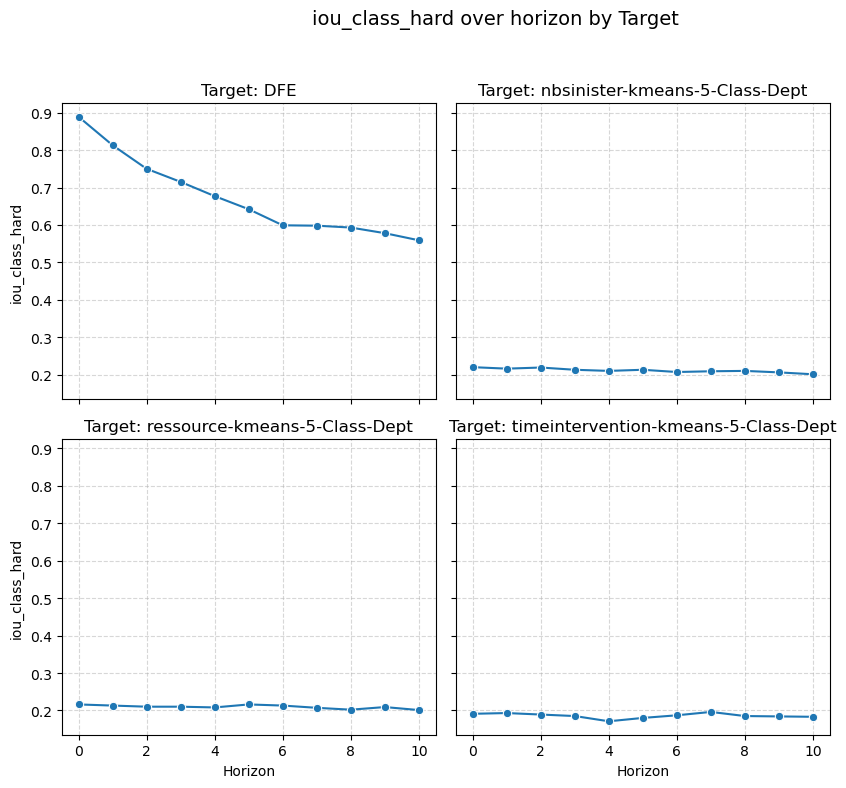

In [32]:
df_test = df[(df['Model'] == 'GRU') & (df['Loss_function'] == 'wkloss') & ((df['Department'] == 6) | (df['Department'] == 'departement-06-alpes-maritimes'))]

df_test['horizon'] = df_test['horizon'].astype(int)

#plot_metric_over_horizon_by_target(df_test, 'auoc')
#plot_metric_over_horizon_by_target(df_test, 'f1_macro')
plot_metric_over_horizon_by_target(df_test, 'iou_class_hard')